<a href="https://colab.research.google.com/github/HrushikeshRokade/Chat-GPT-Review/blob/main/Chat_GPT_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df=pd.read_csv('/content/sample_data/chatgpt_reviews.csv')

In [91]:
print(f'Rows:{df.shape[0]},Colloms:{df.shape[1]}')

Rows:196727,Colloms:4


In [92]:
df.head(5)

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [93]:
df.isnull().sum()

,0
Review Id,0
Review,6
Ratings,0
Review Date,0


In [94]:
df['Review']=df['Review'].fillna('No Review')

In [95]:
df.isnull().sum()

,0
Review Id,0
Review,0
Ratings,0
Review Date,0


In [96]:
df.columns=df.columns.str.lower().str.replace(' ','_')

In [97]:
df.columns

Index(['review_id', 'review', 'ratings', 'review_date'], dtype='object')

In [98]:
df.dtypes

,0
review_id,object
review,object
ratings,int64
review_date,object


In [99]:
df['review_date']=pd.to_datetime(df['review_date'])
print(df['review_date'].dtypes)

datetime64[ns]


In [100]:
df['ratings'].describe()

,ratings
count,196727.000000
mean,4.503535
std,1.083004
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


In [101]:
value=df["ratings"].value_counts().sort_index()
print(value)

ratings
1     12083
2      3375
3      8157
4     22897
5    150215
Name: count, dtype: int64


**Sentiment Analysis Ratings**

In [102]:

df['sentiment']=df['ratings'].apply(
    lambda x :'Positive' if x>=4 else('Neutral' if x==3 else 'Negative')
)
print(df['sentiment'].value_counts())


sentiment
Positive    173112
Negative     15458
Neutral       8157
Name: count, dtype: int64


In [103]:
sentiment_grouping=df.groupby('sentiment')['ratings'].mean()
print(sentiment_grouping)

sentiment
Negative    1.218334
Neutral     3.000000
Positive    4.867733
Name: ratings, dtype: float64


**Sentiment Analysis Reviews**

In [104]:
!pip install textblob
from textblob import TextBlob
import pandas as pd

def get_sentiment_polarity(text):
  if text == 'No Review':
    return 0
  else:
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_polarity'] = df['review'].apply(get_sentiment_polarity)

In [105]:
df['sentiment_polarity_group']=df['sentiment_polarity'].apply(
    lambda x:'Positive' if x>0.10 else('Negative' if x<=-0.10 else 'Neutral')
)

**Visual Representation**

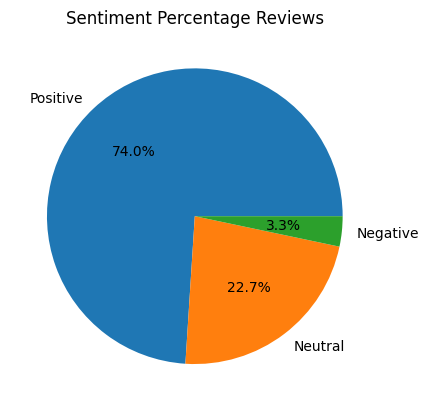

In [106]:
plt.pie(df['sentiment_polarity_group'].value_counts(),labels=df['sentiment_polarity_group'].value_counts().index,autopct='%1.1f%%')
plt.ylabel("")
plt.title('Sentiment Percentage Reviews')
plt.show()

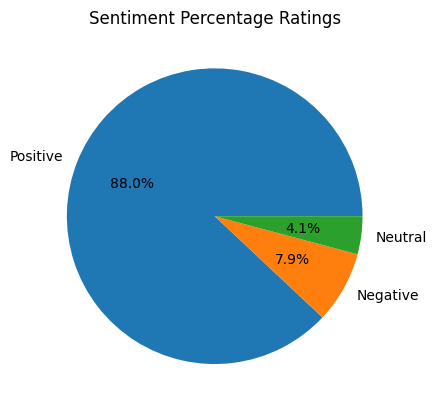

In [107]:
plt.pie(df['sentiment'].value_counts(),labels=df['sentiment'].value_counts().index,autopct='%1.1f%%')
plt.ylabel("")
plt.title('Sentiment Percentage Ratings')
plt.show()

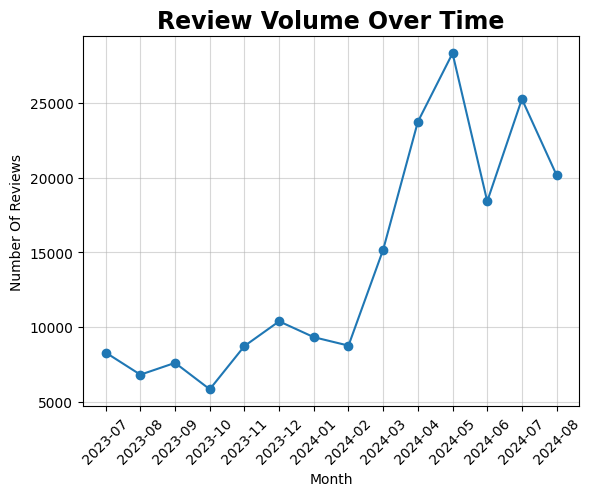

In [108]:
df['month_year'] = df['review_date'].dt.to_period('M')
monthly_size=df.groupby('month_year').size()

plt.plot(monthly_size.index.astype(str),monthly_size.values,marker='o')

plt.title('Review Volume Over Time',fontsize=17,fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number Of Reviews')
plt.xticks(rotation=45)
plt.grid(True,alpha=0.5)
plt.show()

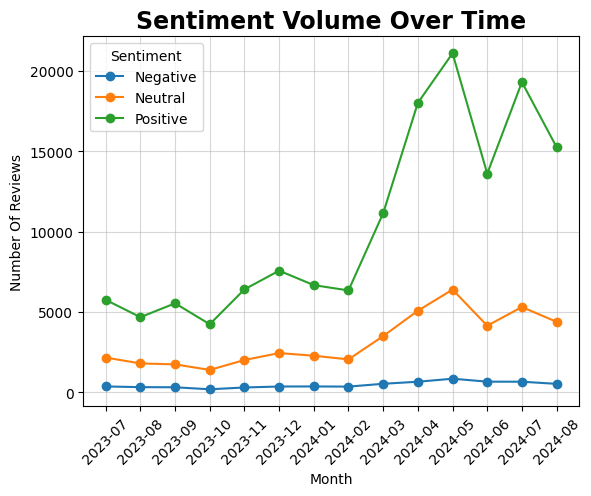

In [109]:
sentiment_over_time=df.groupby(['month_year','sentiment_polarity_group']).size().unstack(fill_value=0)

for column in sentiment_over_time.columns:
    plt.plot(
        sentiment_over_time.index.astype(str),
        sentiment_over_time[column],
        marker='o',
        label=column
    )

plt.title('Sentiment Volume Over Time', fontsize=17, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Number Of Reviews')
plt.grid(True, alpha=0.5)
plt.legend(title='Sentiment')
plt.show()

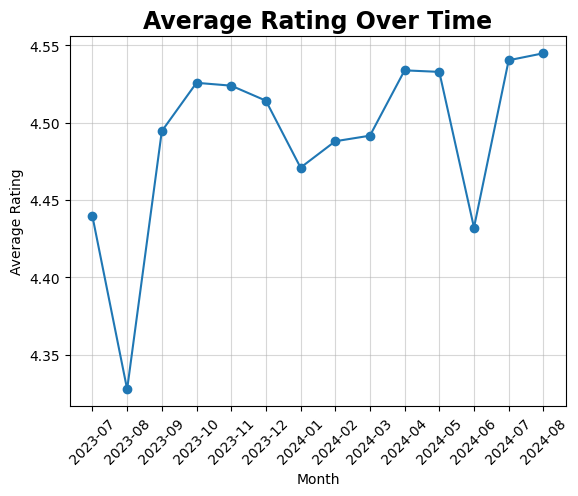

In [110]:
df['month_year'] = df['review_date'].dt.to_period('M')

monthly=df.groupby('month_year')['ratings'].mean()

plt.plot(monthly.index.astype(str),monthly.values,marker='o')
plt.title('Average Rating Over Time',fontsize=17,fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(True,alpha=0.5)
plt.show()

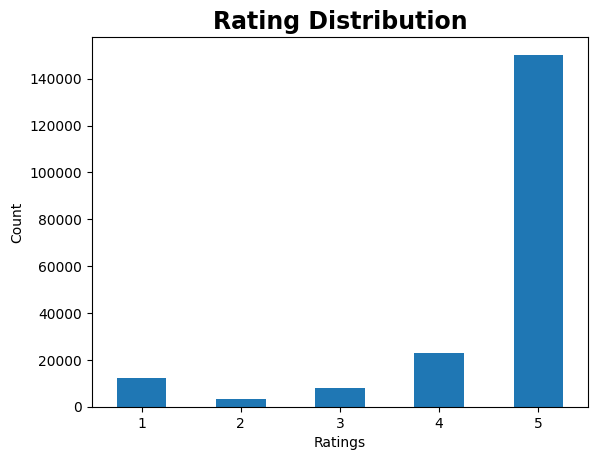

In [111]:
import matplotlib.pyplot as plt

value.sort_index().plot(kind="bar")

plt.xlabel("Ratings")
plt.ylabel("Count")
plt.title("Rating Distribution",fontsize=17,fontweight='bold')
plt.xticks(rotation='horizontal')


plt.show()

In [112]:
df.head(50)

,review_id,review,ratings,review_date,sentiment,sentiment_polarity,sentiment_polarity_group,month_year
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,Positive,0.700000,Positive,2024-08
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,Positive,0.700000,Positive,2024-08
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,Positive,0.600000,Positive,2024-08
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,Positive,0.600000,Positive,2024-08
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,Positive,0.412500,Positive,2024-08
5,9cdc3f78-15cd-4e9d-9287-31bc5af496c4,so nice app,5,2024-08-23 19:18:35,Positive,0.600000,Positive,2024-08
6,3c26ee92-4d72-45ee-9242-caab930903ca,"just love this app, or guy",4,2024-08-23 19:14:40,Positive,0.500000,Positive,2024-08
7,f293ed19-688a-42e2-8282-ddd077771a94,great app,1,2024-08-23 19:12:00,Negative,0.800000,Positive,2024-08
8,99af016c-6db2-4f24-9952-cb3bece40be8,Very impressive,5,2024-08-23 19:11:46,Positive,1.000000,Positive,2024-08
9,27dd6ea5-ada3-4795-a297-6faa7d4b6ba2,helps with coding a lot this ai is great for e...,5,2024-08-23 19:11:09,Positive,0.800000,Positive,2024-08
